## setup

In [ ]:
import pandas as pd 
import textdescriptives as td
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

# !python -m spacy download de_core_news_md
# nlp = spacy.load('de_core_news_md')  # 

In [17]:
df_full = pd.read_parquet(r'/work/PENPAL/PENPAL_analysis/Berlin/Scripts & analyses/data/story_text_field_w_embeddings_jina.parquet')
df_full_de = df_full[df_full['language'] == 'de']

## compute surface metrics

In [9]:
td.get_valid_metrics()

{'all',
 'coherence',
 'dependency_distance',
 'descriptive_stats',
 'information_theory',
 'pos_proportions',
 'quality',
 'readability'}

In [4]:
def get_descriptive_metrics(df:pd.DataFrame, text_column:str, spacy_mdl:str="de_core_news_md", batch_size:int=5, n_process:int=5):
    '''
    Extract low level descriptive features doc_length, n_tokens, n_characters and n_sentences 
    '''
    # load nlp, add td to model
    print(f"[INFO:] Loading SpaCY model '{spacy_mdl}'...")
    nlp = spacy.load(spacy_mdl)
    nlp.add_pipe("textdescriptives/all") 

    # pass txt to pipeline
    text = df[text_column]
    print(f"[INFO:] Passing text from column '{text_column}' to pipeline ...")
    docs = nlp.pipe(text, batch_size=batch_size, n_process=n_process)

    print("[INFO:] Extracting metrics to df ...")
    metrics_df = td.extract_df(docs, include_text=True)

    # subset metrics to only include low level features, then concat
    # metrics_df = metrics_df[["doc_length", "n_tokens", "n_characters", "n_sentences"]]
    # final_df = pd.concat([df, metrics_df], axis=1)

    return metrics_df

In [5]:
df_metrics_user = get_descriptive_metrics(df=df_full_de, text_column='full_user')

[INFO:] Loading SpaCY model 'de_core_news_md'...
[INFO:] Passing text from column 'full_user' to pipeline ...
[INFO:] Extracting metrics to df ...


In [6]:
df_metrics_ai = get_descriptive_metrics(df=df_full_de, text_column='full_ai')

[INFO:] Loading SpaCY model 'de_core_news_md'...
[INFO:] Passing text from column 'full_ai' to pipeline ...
[INFO:] Extracting metrics to df ...


In [14]:
df_metrics_user.columns

Index(['text', 'passed_quality_check', 'n_stop_words', 'alpha_ratio',
       'mean_word_length', 'doc_length', 'symbol_to_word_ratio_#',
       'proportion_ellipsis', 'proportion_bullet_points',
       'contains_lorem ipsum', 'duplicate_line_chr_fraction',
       'duplicate_paragraph_chr_fraction', 'duplicate_ngram_chr_fraction_5',
       'duplicate_ngram_chr_fraction_6', 'duplicate_ngram_chr_fraction_7',
       'duplicate_ngram_chr_fraction_8', 'duplicate_ngram_chr_fraction_9',
       'duplicate_ngram_chr_fraction_10', 'top_ngram_chr_fraction_2',
       'top_ngram_chr_fraction_3', 'top_ngram_chr_fraction_4', 'oov_ratio',
       'dependency_distance_mean', 'dependency_distance_std',
       'prop_adjacent_dependency_relation_mean',
       'prop_adjacent_dependency_relation_std', 'entropy', 'perplexity',
       'per_word_perplexity', 'token_length_mean', 'token_length_median',
       'token_length_std', 'sentence_length_mean', 'sentence_length_median',
       'sentence_length_std', 'syll

In [7]:
df_metrics_ai['type'] = 'ai'
df_metrics_user['type'] = 'user'

In [8]:
df_metrics = pd.concat([df_metrics_ai, df_metrics_user])

In [35]:
df_long = df_metrics.melt(id_vars='type', value_vars=readability, var_name='metric', value_name='value')

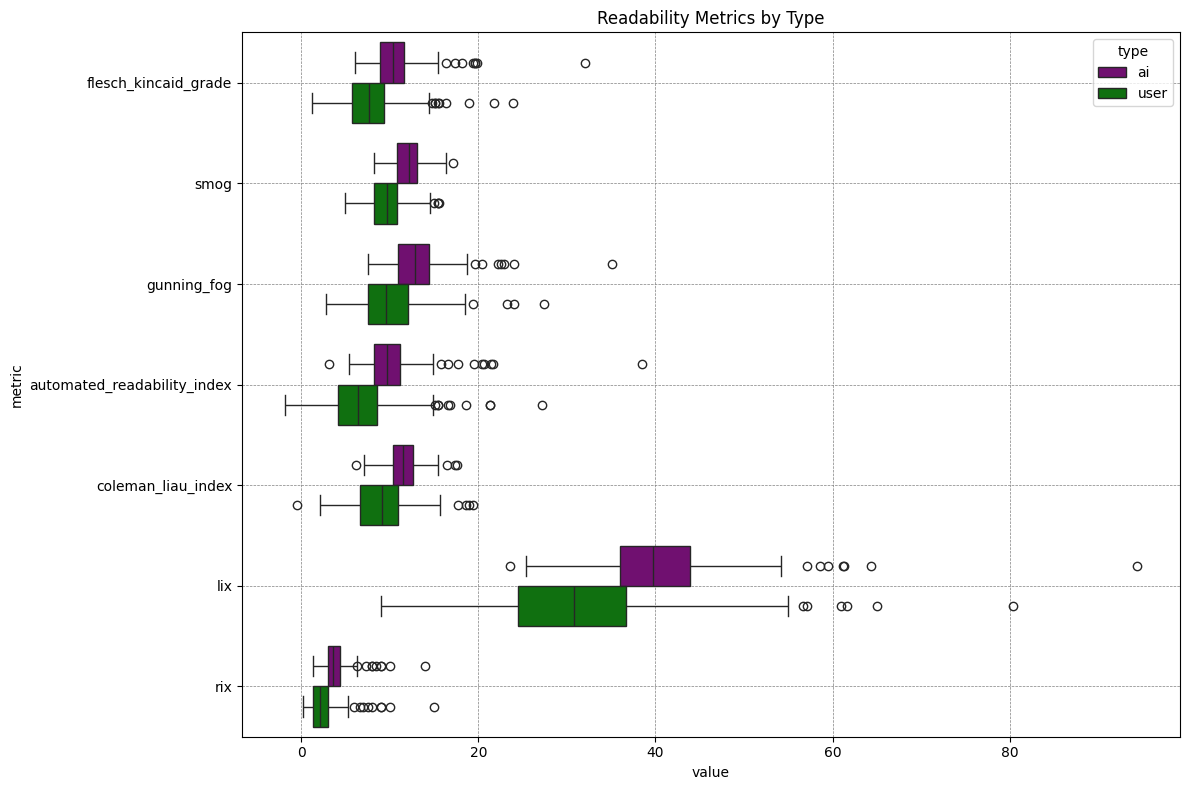

In [41]:
readability = ['flesch_kincaid_grade', 'smog',
       'gunning_fog', 'automated_readability_index', 'coleman_liau_index',
       'lix', 'rix']

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # readability metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Readability Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


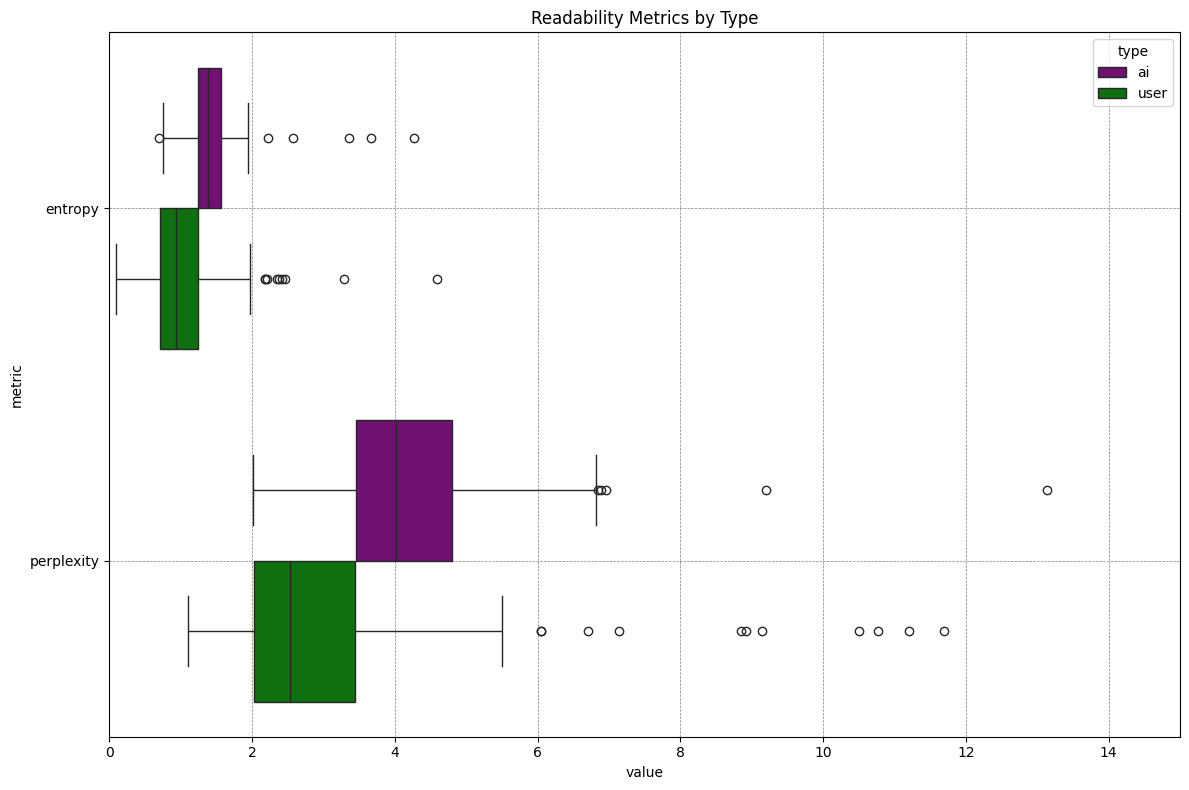

In [ ]:
complexity = ['entropy', 'perplexity']
df_long = df_metrics.melt(id_vars='type', value_vars=complexity, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)

cut_off = 15
plt.xlim((0, cut_off))
plt.title('Complexity Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


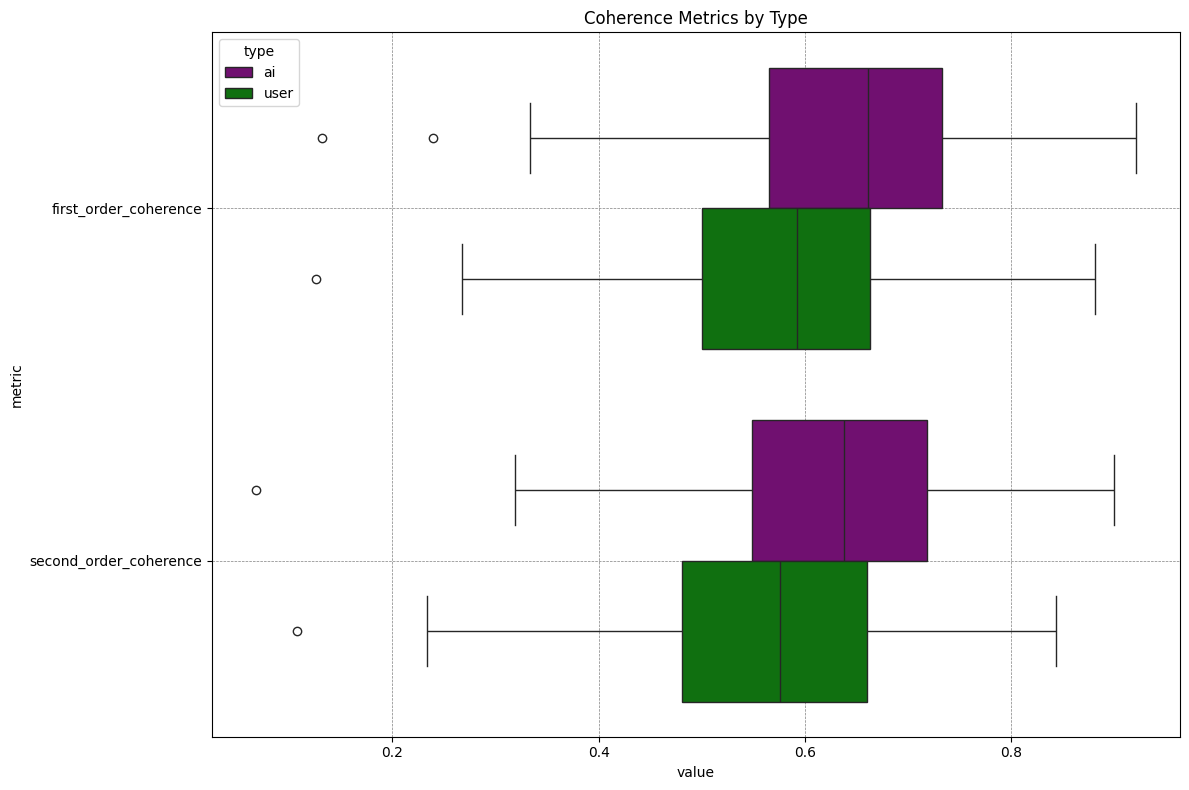

In [67]:
coherence = ['first_order_coherence', 'second_order_coherence']
df_long = df_metrics.melt(id_vars='type', value_vars=coherence, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Coherence Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

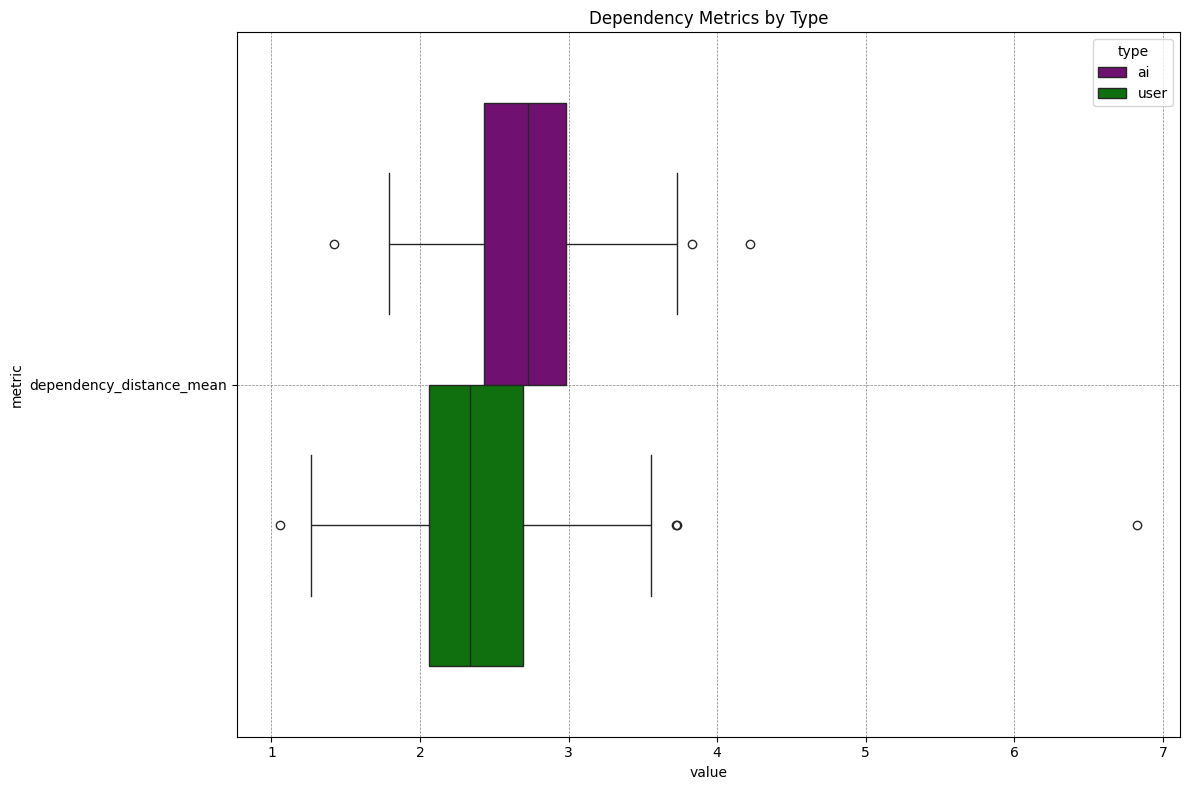

In [6]:
dependency = ['dependency_distance_mean']
df_long = df.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

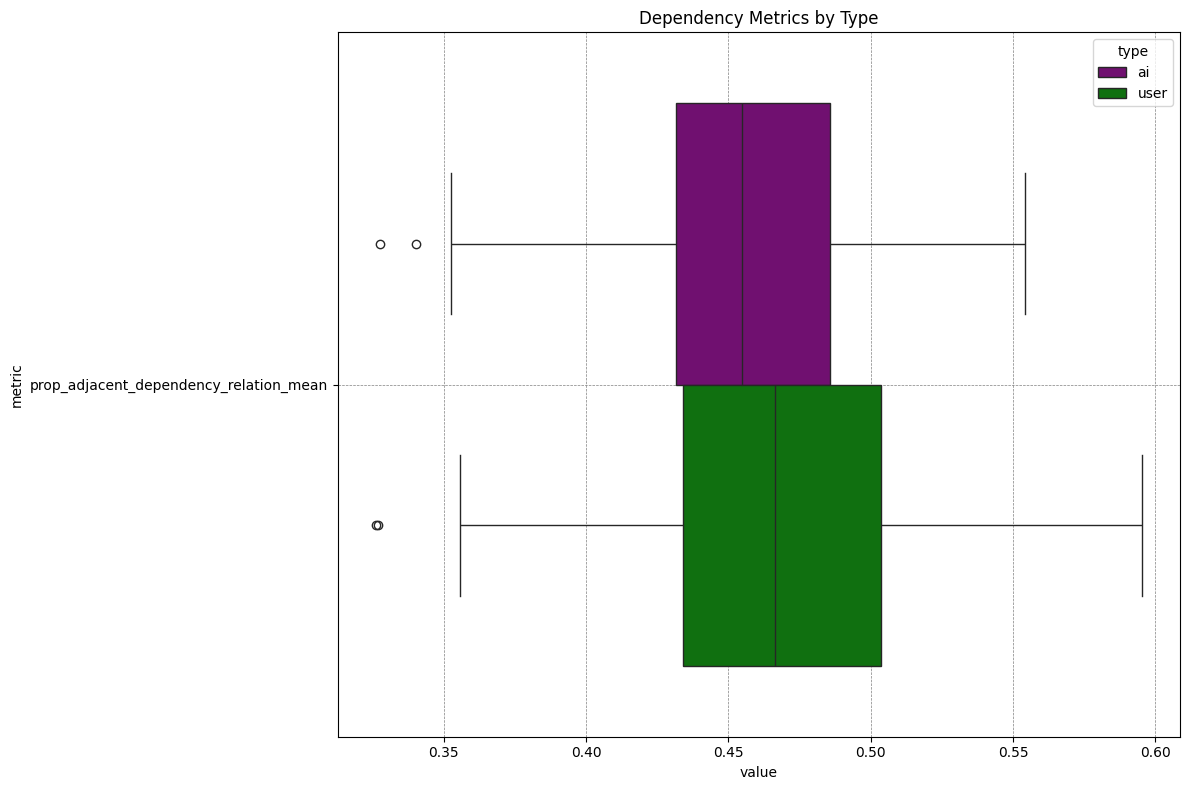

In [7]:
dependency = ['prop_adjacent_dependency_relation_mean']
df_long = df.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

In [3]:
df.columns

Index(['text', 'dependency_distance_mean', 'dependency_distance_std',
       'prop_adjacent_dependency_relation_mean',
       'prop_adjacent_dependency_relation_std', 'passed_quality_check',
       'n_stop_words', 'alpha_ratio', 'mean_word_length', 'doc_length',
       'symbol_to_word_ratio_#', 'proportion_ellipsis',
       'proportion_bullet_points', 'contains_lorem ipsum',
       'duplicate_line_chr_fraction', 'duplicate_paragraph_chr_fraction',
       'duplicate_ngram_chr_fraction_5', 'duplicate_ngram_chr_fraction_6',
       'duplicate_ngram_chr_fraction_7', 'duplicate_ngram_chr_fraction_8',
       'duplicate_ngram_chr_fraction_9', 'duplicate_ngram_chr_fraction_10',
       'top_ngram_chr_fraction_2', 'top_ngram_chr_fraction_3',
       'top_ngram_chr_fraction_4', 'oov_ratio', 'flesch_reading_ease',
       'flesch_kincaid_grade', 'smog', 'gunning_fog',
       'automated_readability_index', 'coleman_liau_index', 'lix', 'rix',
       'entropy', 'perplexity', 'per_word_perplexity', 'toke

### Overview

In [2]:
df = pd.read_parquet('metrics/surface_metrics.parquet')

In [3]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

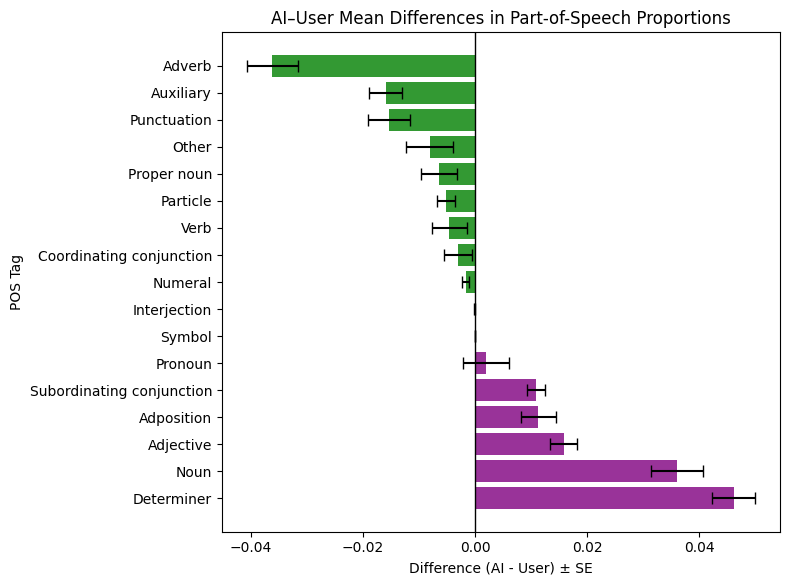

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metrics = [col for col in df.columns if col.startswith('pos_')]

# Compute group stats
group_means = df.groupby('type')[metrics].mean().T
group_sds = df.groupby('type')[metrics].std().T
group_ns = df['type'].value_counts()

# Standard error of the difference: sqrt(s1²/n1 + s2²/n2)
se_diff = np.sqrt(
    (group_sds['ai']**2 / group_ns['ai']) +
    (group_sds['user']**2 / group_ns['user'])
)

# Difference in means
group_means['diff'] = group_means['ai'] - group_means['user']
group_means['se_diff'] = se_diff

# Sort for display
subset = group_means.sort_values('diff', ascending=False)
subset = subset.rename(index = lambda col: pos_names.get(col.split('_')[-1], col).capitalize())

# --- Plot ---
plt.figure(figsize=(8, max(4, len(subset)*0.35)))
colors = subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')


plt.barh(
    subset.index,
    subset['diff'],
    xerr=subset['se_diff'],
    color=colors,
    # ecolor=colors,          # match bar color
    capsize=4,
    alpha=0.8
)

plt.axvline(0, color='black', linewidth=1)
plt.title("AI–User Mean Differences in Part-of-Speech Proportions")
plt.xlabel("Difference (AI - User) ± SE")
plt.ylabel("POS Tag")
plt.tight_layout()
plt.show()


In [11]:
subset

type,ai,user,diff,se_diff
determiner,0.135404,0.089326,0.046078,0.003766
noun,0.175823,0.139784,0.036039,0.004617
adjective,0.043580,0.027797,0.015783,0.002460
adposition,0.078656,0.067394,0.011262,0.003167
subordinating conjunction,0.023539,0.012685,0.010853,0.001680
pronoun,0.118112,0.116188,0.001924,0.004051
symbol,0.000000,0.000000,0.000000,0.000000
interjection,0.000000,0.000099,-0.000099,0.000099
numeral,0.000475,0.002162,-0.001687,0.000587
coordinating conjunction,0.036720,0.039811,-0.003091,0.002484


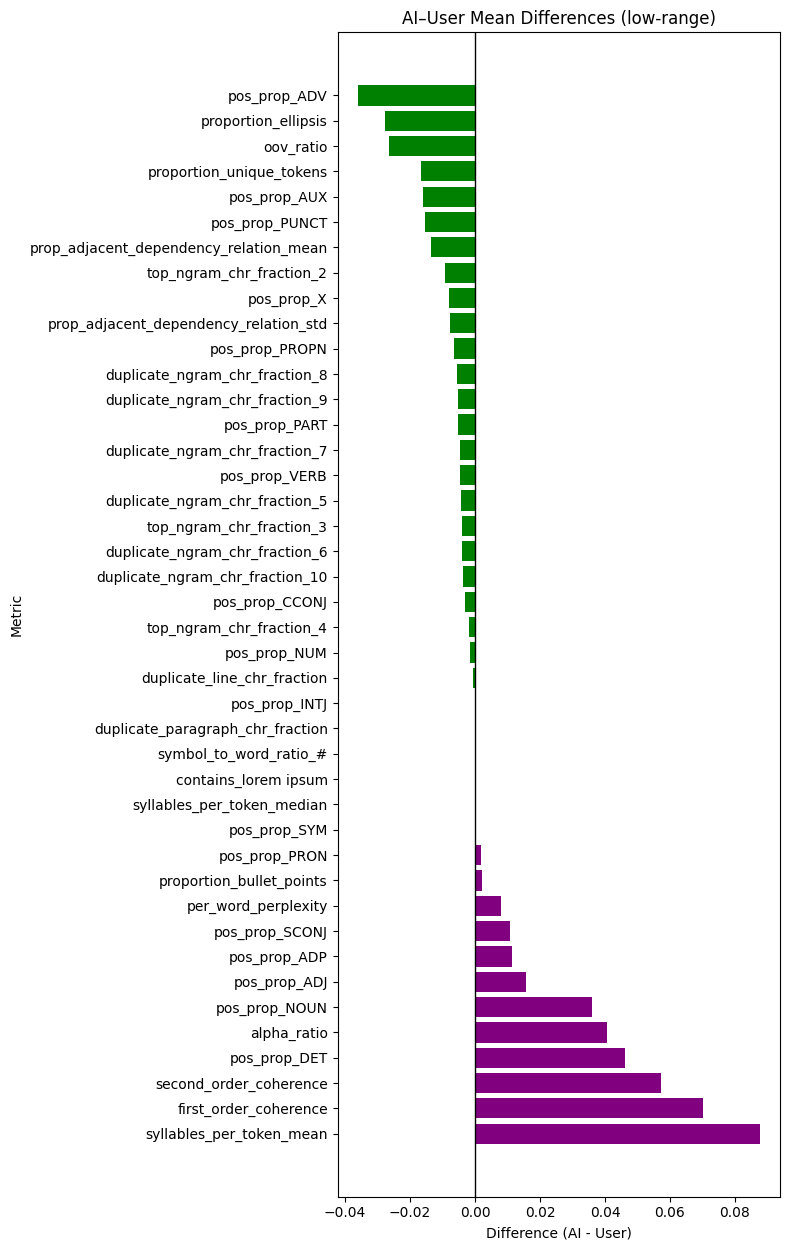

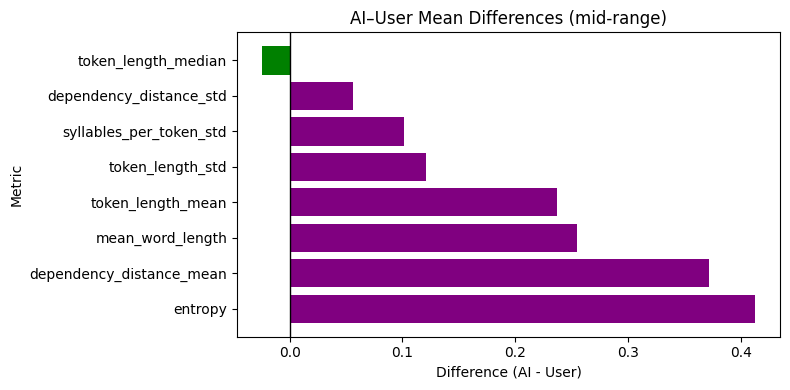

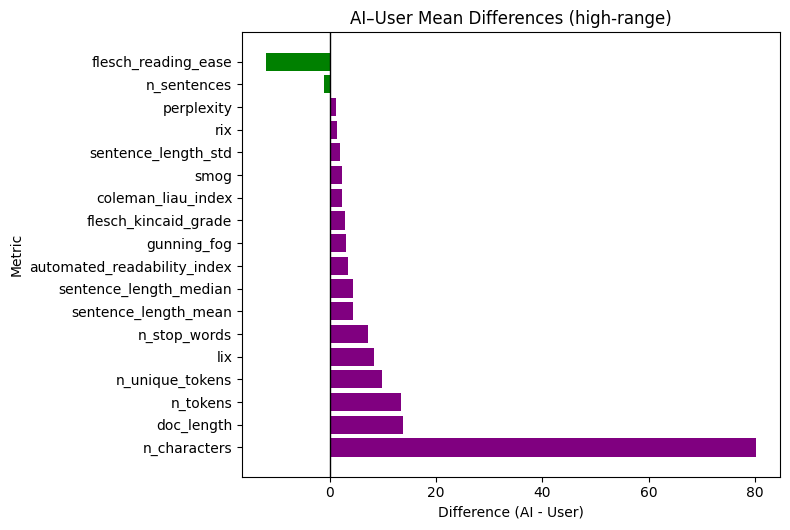

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Setup ---
df_numeric = df.select_dtypes('number')
metrics = df_numeric.columns

# Compute mean per type
group_means = df.groupby('type')[metrics].mean().T
group_means['diff'] = group_means['ai'] - group_means['user']

# Compute ranges for grouping
min_vals = df_numeric.min()
max_vals = df_numeric.max()
ranges = max_vals - min_vals

# Define thresholds (tune if needed)
low_thr, mid_thr = 1, 10  # <1 small fractions, 1–10 mid, >10 high-range metrics

# Assign each metric to a scale group
scale_group = pd.cut(ranges, 
                     bins=[-np.inf, low_thr, mid_thr, np.inf], 
                     labels=['low-range', 'mid-range', 'high-range'])

group_means['scale_group'] = scale_group

# --- Plot each scale group separately ---
for group in ['low-range', 'mid-range', 'high-range']:
    subset = group_means[group_means['scale_group'] == group].sort_values('diff', ascending=False)
    if subset.empty:
        continue

    plt.figure(figsize=(8, max(4, len(subset)*0.3)))
    plt.barh(
        subset.index,
        subset['diff'],
        color=subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')
    )
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f"AI–User Mean Differences ({group})")
    plt.xlabel("Difference (AI - User)")
    plt.ylabel("Metric")
    plt.tight_layout()
    plt.show()


## z-scored

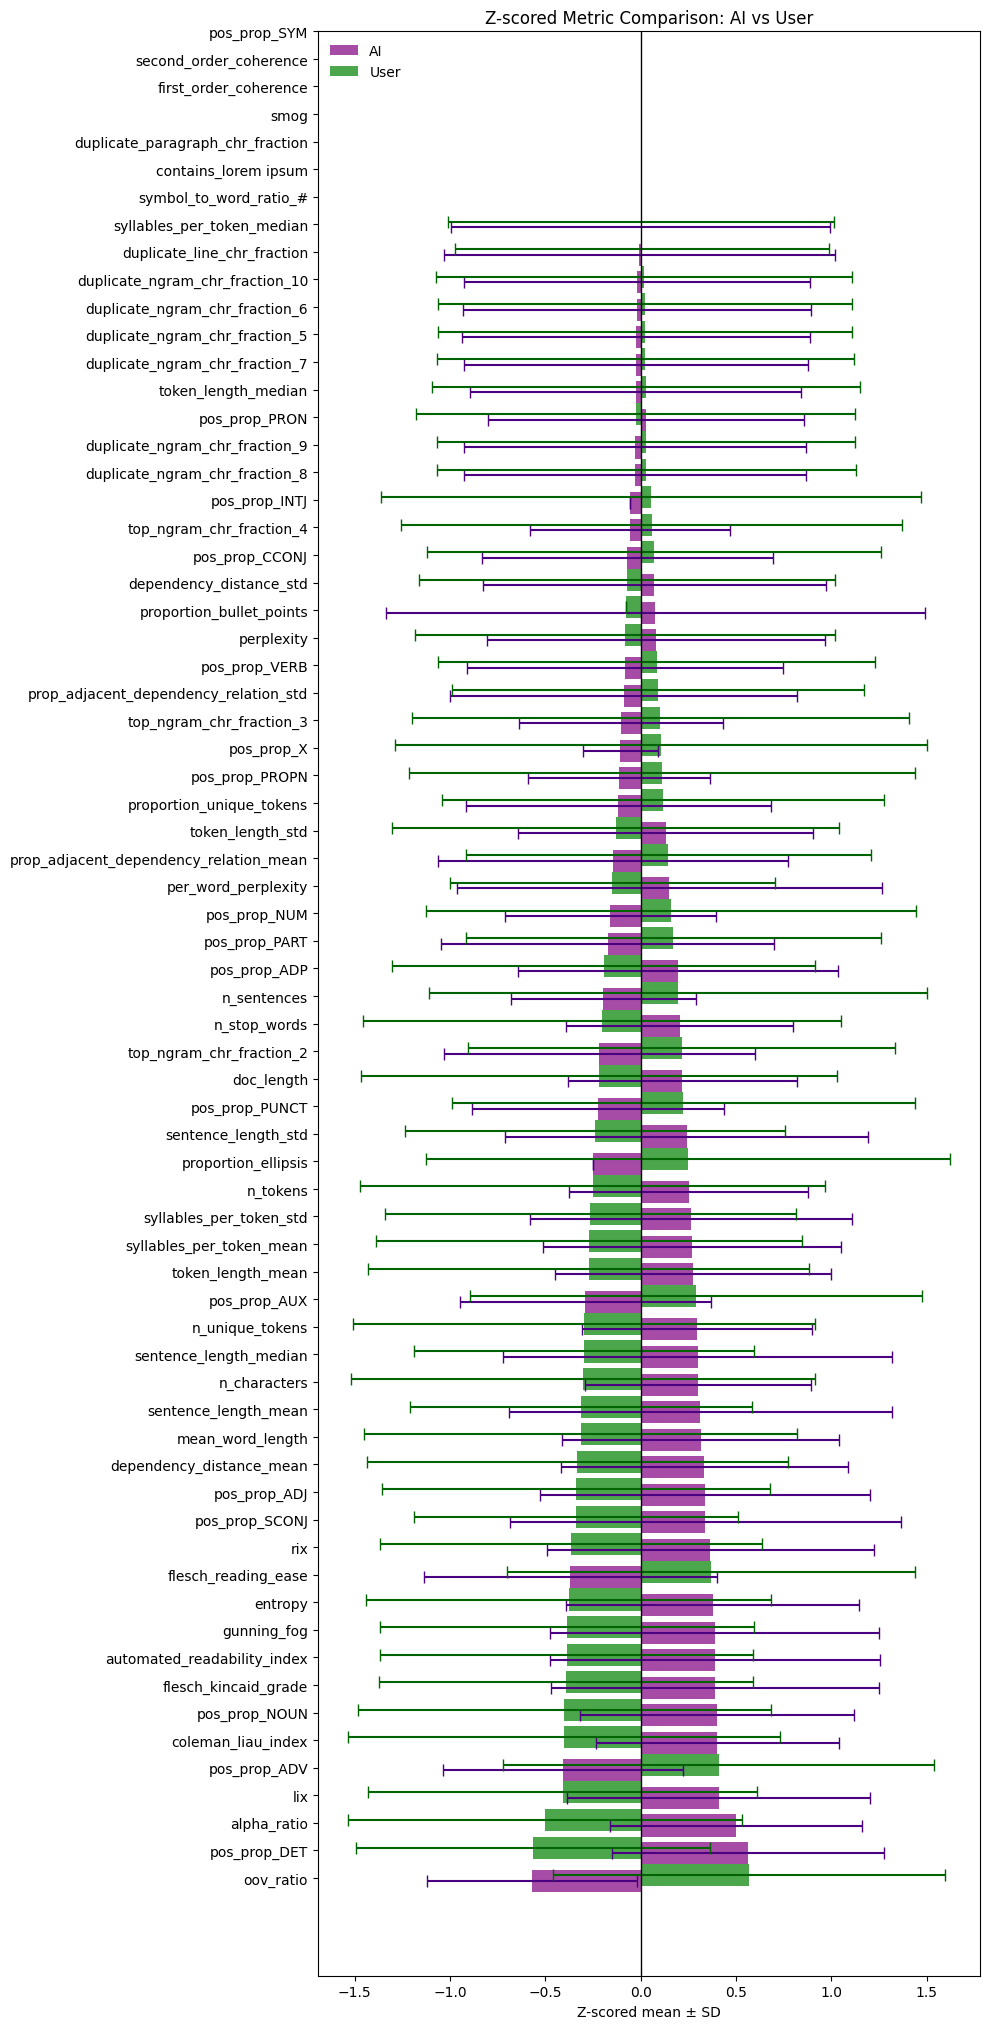

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# --- Z-score numeric metrics ---
df_numeric = df.select_dtypes('number')
metrics = df_numeric.columns
df_z = df_numeric.apply(zscore)
df_z['type'] = df['type']

# --- Compute means & sds ---
group_means = df_z.groupby('type')[metrics].mean().T
group_sds   = df_z.groupby('type')[metrics].std().T
group_means['diff'] = group_means['ai'] - group_means['user']

# --- Sort by absolute difference ---
order = group_means['diff'].abs().sort_values(ascending=False).index
x = np.arange(len(order))
width = 0.2

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, max(5, len(metrics)*0.3)))

# AI bars with purple error bars
ax.barh(x - width/2, group_means.loc[order, 'ai'],
        xerr=group_sds.loc[order, 'ai'],
        label='AI',
        color='purple', alpha=0.7, capsize=4, ecolor='indigo')

# User bars with green error bars
ax.barh(x + width/2, group_means.loc[order, 'user'],
        xerr=group_sds.loc[order, 'user'],
        label='User',
        color='green', alpha=0.7, capsize=4, ecolor='darkgreen',)

# Cosmetic tweaks
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(x)
ax.set_yticklabels(order)
ax.set_xlabel("Z-scored mean ± SD")
ax.set_title("Z-scored Metric Comparison: AI vs User")
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


In [30]:
df[df['alpha_ratio'] > 0.5].loc[:,['alpha_ratio']]

,alpha_ratio
index,
0,0.822335
1,0.860759
2,0.848958
3,0.836449
4,0.817204
...,...
156,0.789474
157,0.828125
158,0.835294


In [32]:
df['alpha_ratio'].sort_values(ascending=True)

index
127    0.647059
62     0.647059
127    0.666667
93     0.673913
131    0.685185
         ...   
138    0.863636
91     0.865169
48     0.867347
89     0.875000
31     0.882979
Name: alpha_ratio, Length: 322, dtype: float64